<a href="https://colab.research.google.com/github/andysanchez1403-droid/ANDREA-GLZ-SNZ/blob/main/Tarea_1_PRUEBA_DE_PROMEDIOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PRUEBA DE LOS PROMEDIOS**

Conociendo la distribución uniforme, es posible plantear una prueba de hipótesis de promedios con la cual se trata de probar que los números pseudoaleatorios generados provienen de un universo uniforme, la cual puede ser planteada de la siguiente manera:

**Hipótesis nula** $$H_0: \mu = \big (\frac {1}{2} \big)$$

**Hipótesis alternativa**

$$H_1: \mu \neq \big (\frac {1}{2} \big)$$

La realización de esta prueba requiere obtener una muestra de tamaño **N**, es decir es necesario generar **N** números pseudoaleatorios. En seguida, su promedio aritmético es evaluado de acuerdo a la siguiente expresión:

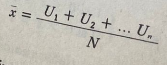

En seguida podemos notar que se determina el valor del estadístico $Z_{0}$, utilizando la siguiente expresión:

$$Z_0=\frac{\bar{x}-\frac{1}{2}\sqrt{N}}{\sqrt(\frac{1}{12})}$$

Si |$Z_{0}$| < Z entonces no se puede rechazar la hipótesis de los números pseudoaleatorios presentadosa en la siguiente tabla:

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

#GENERADOR DE DATOS
#SIMULAREMOS LA MUESTRA

N= 100
np.random.seed(42)
numeros = np.random.uniform(0,1,N)

print(f"ANÁLISIS DE {N} NÚMEROS PSEUDOALETORIOS")

ANÁLISIS DE 100 NÚMEROS PSEUDOALETORIOS


A continuación con ayuda de la tabla 3.1 de números pseudoaleatorios hacemos uso de la teoría mencionada con anterioridad.

La cual esta se encuentra en un archivo de Excel llamado DATOS.

In [34]:
import pandas as pd

# Extraemos el url de Github donde está ubiccado el excel
url = 'https://github.com/andysanchez1403-droid/ANDREA-GLZ-SNZ/raw/main/DATOS.xlsx'

# Leemos el archivo de Excel
# Nota: Si marca error de openpyxl, corre primero: !pip install openpyxl
df = pd.read_excel(url, engine='openpyxl')

# Extraer y aplanar los datos
datos_todos = df.values.flatten()

# Cálculos de promedio
N = len(datos_todos)
promedio = sum(datos_todos) / N

# Resultados
print(f"Archivo cargado desde: {url}")
print(f"Total de datos (N): {N}")
print(f"Promedio final (x̄): {promedio:.5f}")

Archivo cargado desde: https://github.com/andysanchez1403-droid/ANDREA-GLZ-SNZ/raw/main/DATOS.xlsx
Total de datos (N): 100
Promedio final (x̄): 0.48234


In [35]:
import numpy as np
import scipy.stats as st
data = df.values.flatten()

In [36]:
def promedios(data, alfa):
  x = np.mean(data)
  N = len(data)
  z = (x-0.5)*np.sqrt(N) /np.sqrt(1/12)
  z_c = st.norm.ppf(1 - alfa/2)

  if abs(z) < z_c:
      print("No se rechaza $H_0$: La muestra proviene de una distribución u(0,1)")
  else:
      print("Se rechaza $H_0$: La nuestra no proviene de una distribución u(0,1)")

promedios(data, 0.05)

No se rechaza $H_0$: La muestra proviene de una distribución u(0,1)


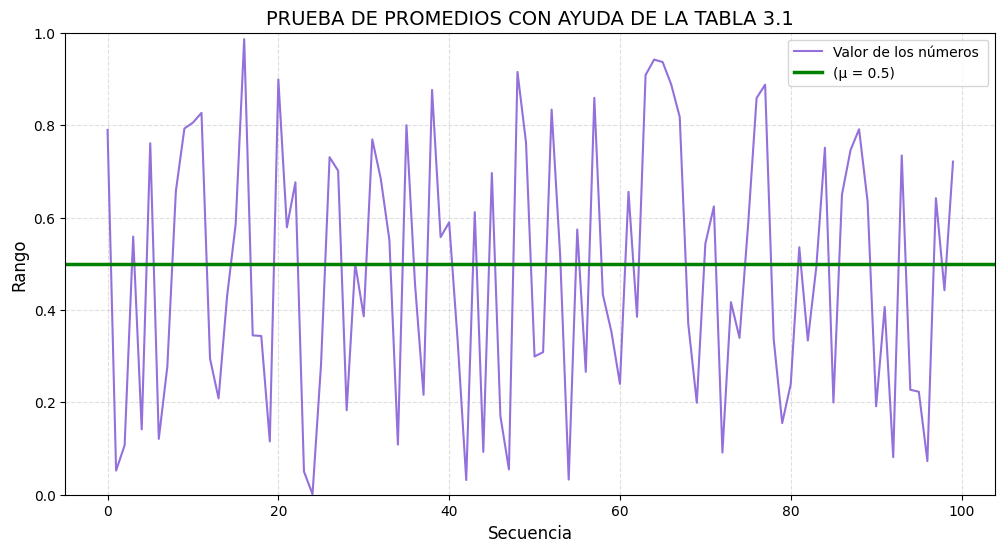

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar los datos del Excel
df = pd.read_excel('DATOS.xlsx')
data = df.values.flatten()
indices = np.arange(len(data))

# 2. Configurar la gráfica
plt.figure(figsize=(12, 6))

# Dibujar la línea de los datos (Lila)
plt.plot(indices, data, color='mediumpurple', linewidth=1.5, label='Valor de los números ')

# Dibujar la línea de la media teórica mu = 0.5 (Verde)
plt.axhline(y=0.5, color='green', linestyle='-', linewidth=2.5, label='(μ = 0.5)')

# 3. Personalización
plt.title('PRUEBA DE PROMEDIOS CON AYUDA DE LA TABLA 3.1', fontsize=14)
plt.xlabel('Secuencia', fontsize=12)
plt.ylabel('Rango', fontsize=12)
plt.ylim(0, 1) # Rango de 0 a 1
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()